# Bronx and Queens Modeling

Model comparisons for Bronx and Queens. Models compared here are SARIMA, XGBoost, Ridge Regression, Prophet, and an Ensemble model combining these models. The model comparisons are made on data from 2020-01-01 to 2025-02-28 inclusive which the data from 2025-03-01 to 2026-02-28 being used for final model evaluations.

## Import Packages

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
from statsmodels.tsa.statespace.sarimax import SARIMAX

## Preporatory Functions and Variables

In [2]:
# Directories
DATA_DIR = Path("../../scr/data")  # updated relative path
FIG_DIR  = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

# Time series CV settings
N_SPLITS  = 26
TEST_SIZE = 14
MIN_TRAIN = 365

# Define functions for metrics
def rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((np.array(y_true) - np.array(y_pred))**2)))

def mape_safe(y_true, y_pred):
    y_true, y_pred = np.array(y_true, float), np.array(y_pred, float)
    mask = y_true != 0
    if mask.sum() < len(y_true) * 0.5:
        return np.nan
    
    
    
# Make a function which prepares a dataframe for SARIMAX

def make_sarima_series(df):
    s = df.set_index("ds")["count"]
    s = s.reindex(pd.date_range(s.index.min(), s.index.max(), freq="D"), fill_value=0)
    s.index.freq = pd.tseries.frequencies.to_offset("D")
    return s

## Load and Prepare the Data

In [3]:
rats_raw = pd.read_csv(DATA_DIR / "rat_sightings_data" / "Rat_Sightings_NYC.csv")

In [4]:
def clean_rats(df):
    df = df.copy()
    df.columns = df.columns.str.strip()
    df["created_dt"] = pd.to_datetime(df["Created Date"], errors="coerce")
    df["zip_clean"]  = df["Incident Zip"].astype(str).str.strip().str.extract(r"(\d{5})")[0]
    df["borough"]    = (
        df["Borough"].astype(str).str.upper().str.strip()
        .replace({"THE BRONX": "BRONX", "STATEN IS": "STATEN ISLAND", "NAN": pd.NA, "0": pd.NA})
    )
    df["week"] = df["created_dt"].dt.to_period("W-SUN").dt.start_time
    df = df.dropna(subset=["created_dt", "zip_clean"])
    df = df[df["created_dt"] >= "2020-01-01"].reset_index(drop=True)
    return df

rats = clean_rats(rats_raw)

In [5]:
DATA_CUTOFF = pd.Timestamp("2025-02-28")
print(f"data cutoff: {DATA_CUTOFF.date()}")

def build_daily(df, borough):
    sub = (
        df[df["borough"] == borough]
        .dropna(subset=["created_dt"])
        .groupby(df["created_dt"].dt.date)
        .size()
        .reset_index()
    )
    sub.columns = ["ds", "count"]
    sub["ds"] = pd.to_datetime(sub["ds"])
    sub = sub[sub["ds"] <= DATA_CUTOFF].sort_values("ds")

    if len(sub) == 0:
        print(f"no data for {borough}")
        return None

    full = pd.date_range(sub["ds"].min(), sub["ds"].max(), freq="D")
    sub = sub.set_index("ds").reindex(full, fill_value=0).rename_axis("ds").reset_index()
    return sub

daily_bronx  = build_daily(rats, "BRONX")
daily_queens = build_daily(rats, "QUEENS")

for name, d in [("Bronx", daily_bronx), ("Queens", daily_queens)]:
    print(f"\n{name}: {len(d)} days, mean={d['count'].mean():.1f}, peak={d['count'].max()}")

data cutoff: 2025-02-28

Bronx: 1886 days, mean=10.2, peak=31

Queens: 1886 days, mean=10.4, peak=38


# Plot of Daily Rat Sightings

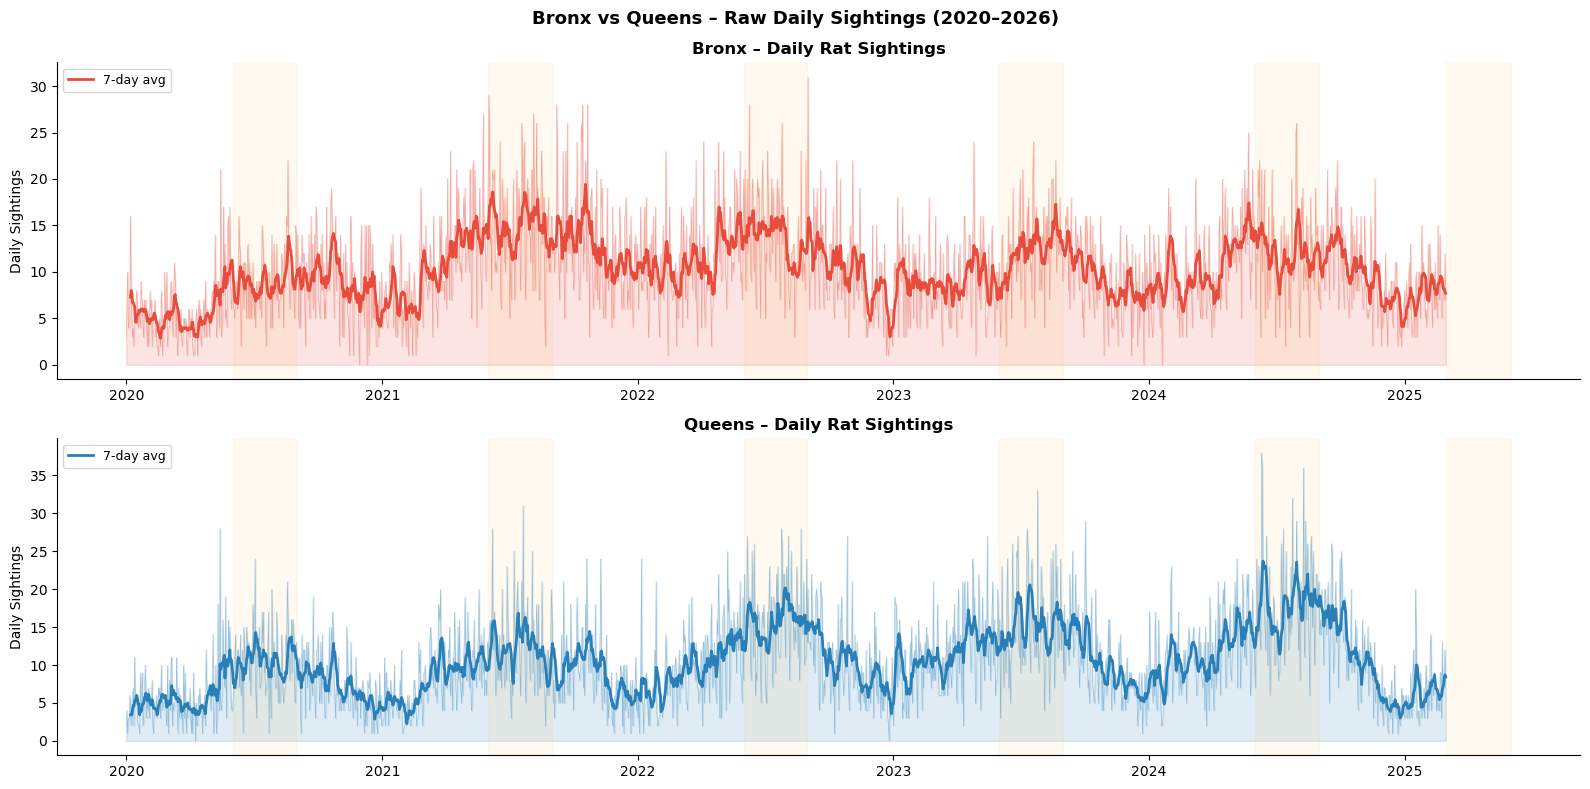

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(16, 8))

for ax, d, name, color in zip(axes,
                               [daily_bronx, daily_queens],
                               ["Bronx", "Queens"],
                               ["#e74c3c", "#2980b9"]):
    roll7 = d.set_index("ds")["count"].rolling(7).mean()
    ax.fill_between(d["ds"], d["count"], alpha=0.15, color=color)
    ax.plot(d["ds"], d["count"], color=color, lw=0.4, alpha=0.4)
    ax.plot(roll7.index, roll7.values, color=color, lw=2, label="7-day avg")

    for yr in range(2020, DATA_CUTOFF.year + 1):
        ax.axvspan(pd.Timestamp(f"{yr}-06-01"),
                   min(pd.Timestamp(f"{yr}-08-31"), DATA_CUTOFF),
                   alpha=0.06, color="orange")

    ax.set_title(f"{name} – Daily Rat Sightings", fontweight="bold")
    ax.set_ylabel("Daily Sightings")
    ax.legend(fontsize=9)
    ax.spines[["top","right"]].set_visible(False)

plt.suptitle("Bronx vs Queens – Raw Daily Sightings (2020–2026)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# First Look at Prophet Model on Both Boroughs

In the other boroughs and at the citywide level, we saw that Prophet performed the best. So we start by lookking at Prophet to get an idea for its performance.

In [7]:
def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

def prophet_walkforward(daily_df, borough):
    tscv    = TimeSeriesSplit(n_splits=N_SPLITS, test_size=TEST_SIZE)
    records = []

    for fold, (tr_idx, te_idx) in enumerate(tscv.split(daily_df)):
        
        train = daily_df.iloc[tr_idx].copy()
        test  = daily_df.iloc[te_idx].copy()

        m = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False, 
                    seasonality_mode="additive", changepoint_prior_scale=0.05, interval_width=0.80)
        m.add_country_holidays(country_name="US")

        # fit the model
        m.fit(train.rename(columns={"count": "y"}))

        # have the model make a TEST_SIZE length forecast
        future   = m.make_future_dataframe(periods=TEST_SIZE, freq="D")
        forecast = m.predict(future)
        
        # get the actual forecasts -- this is due to how Prophet's make_future_dataframe functions
        forecast["yhat"] = forecast["yhat"].clip(lower=0)


        
        fc     = forecast.set_index("ds")["yhat"].reindex(pd.DatetimeIndex(test["ds"]), fill_value=0)
        actual = test.set_index("ds")["count"].reindex(fc.index, fill_value=0)


        records.append({"borough": borough, "fold": fold + 1, 
                        "test_start": test["ds"].min().date(),
                        "test_end": test["ds"].max().date(), 
                        "MAE": round(mean_absolute_error(actual, fc), 2), 
                        "RMSE": round(rmse(actual, fc), 2),})

    df = pd.DataFrame(records)

    # Compute overall metrics
    overall = pd.DataFrame([{"borough": borough, "fold": "overall", "test_start": pd.NaT, 
                             "test_end": pd.NaT, "MAE": f"{df['MAE'].mean():.2f}"
                             , "RMSE": f"{df['RMSE'].mean():.2f}"}])

    return pd.concat([df, overall], ignore_index=True)

# Example usage
wf_bronx  = prophet_walkforward(daily_bronx,  "Bronx")
wf_queens = prophet_walkforward(daily_queens, "Queens")

# Combine both boroughs into a single DataFrame for display
wf_all = pd.concat([wf_bronx, wf_queens], ignore_index=True)
wf_all

10:55:17 - cmdstanpy - INFO - Chain [1] start processing
10:55:17 - cmdstanpy - INFO - Chain [1] done processing
10:55:18 - cmdstanpy - INFO - Chain [1] start processing
10:55:18 - cmdstanpy - INFO - Chain [1] done processing
10:55:18 - cmdstanpy - INFO - Chain [1] start processing
10:55:18 - cmdstanpy - INFO - Chain [1] done processing
10:55:19 - cmdstanpy - INFO - Chain [1] start processing
10:55:19 - cmdstanpy - INFO - Chain [1] done processing
10:55:19 - cmdstanpy - INFO - Chain [1] start processing
10:55:19 - cmdstanpy - INFO - Chain [1] done processing
10:55:20 - cmdstanpy - INFO - Chain [1] start processing
10:55:20 - cmdstanpy - INFO - Chain [1] done processing
10:55:20 - cmdstanpy - INFO - Chain [1] start processing
10:55:20 - cmdstanpy - INFO - Chain [1] done processing
10:55:20 - cmdstanpy - INFO - Chain [1] start processing
10:55:21 - cmdstanpy - INFO - Chain [1] done processing
10:55:21 - cmdstanpy - INFO - Chain [1] start processing
10:55:21 - cmdstanpy - INFO - Chain [1]

,borough,fold,test_start,test_end,MAE,RMSE
0,Bronx,1,2024-03-02,2024-03-15,3.2,4.21
1,Bronx,2,2024-03-16,2024-03-29,2.81,3.37
2,Bronx,3,2024-03-30,2024-04-12,2.62,3.18
3,Bronx,4,2024-04-13,2024-04-26,3.12,4.09
4,Bronx,5,2024-04-27,2024-05-10,2.41,2.66
5,Bronx,6,2024-05-11,2024-05-24,4.6,5.78
6,Bronx,7,2024-05-25,2024-06-07,3.49,4.18
7,Bronx,8,2024-06-08,2024-06-21,3.43,4.17
8,Bronx,9,2024-06-22,2024-07-05,3.33,4.17
9,Bronx,10,2024-07-06,2024-07-19,3.24,4.08


# Testing SARIMA, XGBoost, Ridge, and Ensemble Model

Make some comparisons here...where were these models chosen...etc.

In [8]:
import xgboost as xgb
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

In [9]:
# why not also add in weather data?

def make_features(series):
    df = pd.DataFrame({"y": series})
    df["lag14"]     = df["y"].shift(14)
    df["lag15"]     = df["y"].shift(15)
    df["roll7"]     = df["y"].shift(14).rolling(7,  min_periods=1).mean()
    df["roll14"]    = df["y"].shift(14).rolling(14, min_periods=1).mean()
    df["dow"]       = df.index.dayofweek
    df["month"]     = df.index.month
    df["is_summer"] = df["month"].isin([6,7,8]).astype(int)
    df["is_winter"] = df["month"].isin([12,1,2]).astype(int)
    df = df.dropna()
    return df.drop(columns="y"), df["y"].values

The following function does compares each model based on how well it can make 2 week forecasts. There are 26 steps.

In [ ]:
def all_models_walkforward(daily_df, borough):
    tscv    = TimeSeriesSplit(n_splits=N_SPLITS, test_size=TEST_SIZE)
    records = []

    for fold, (tr_idx, te_idx) in enumerate(tscv.split(daily_df)):
        train  = daily_df.iloc[tr_idx].copy()
        test   = daily_df.iloc[te_idx].copy()

        actual   = test["count"].values
        fold_rec = {"borough": borough, "fold": fold+1, "test_start": test["ds"].min().date()}

        # Prophet
        try:
            m = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False, 
                        seasonality_mode="additive", changepoint_prior_scale=0.05, interval_width=0.80)
            m.add_country_holidays(country_name="US")
            m.fit(train.rename(columns={"count":"y"}))
            future = m.make_future_dataframe(periods=TEST_SIZE, freq="D")
            forecast = m.predict(future)
            fc_prophet = np.clip(forecast.set_index("ds")["yhat"].reindex(pd.DatetimeIndex(test["ds"]), fill_value=0).values, 0, None)
        except:
            fc_prophet = np.full(TEST_SIZE, train["count"].mean())

        # SARIMA
        try:
            s_train  = make_sarima_series(train)
            s_fit    = SARIMAX(s_train, order=(1,1,1), seasonal_order=(1,1,1,7), enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
            fc_sarima = np.clip(s_fit.forecast(steps=TEST_SIZE).values, 0, None)
        except:
            fc_sarima = np.full(TEST_SIZE, train["count"].mean())

        # XGBoost
        try:
            s_tr = make_sarima_series(train)
            X_tr, y_tr = make_features(s_tr)
            xgb_m = xgb.XGBRegressor(n_estimators=50,learning_rate=0.1,max_depth=5,
                                     subsample=0.8,colsample_bytree=0.8,min_child_weight=3,gamma=0.1,
                                     reg_alpha=0.1,reg_lambda=1.0,random_state=42,verbosity=0)
            xgb_m.fit(X_tr, y_tr)
            combined = pd.concat([train, test]).reset_index(drop=True)
            s_full   = make_sarima_series(combined)
            X_full, _ = make_features(s_full)
            fc_xgb = np.clip(xgb_m.predict(X_full.tail(TEST_SIZE)), 0, None)
        except:
            fc_xgb = np.full(TEST_SIZE, train["count"].mean())

        # Ridge
        try:
            s_tr = make_sarima_series(train)
            X_tr, y_tr = make_features(s_tr)
            scaler  = StandardScaler()
            ridge   = Ridge(alpha=1.0)
            ridge.fit(scaler.fit_transform(X_tr), y_tr)
            combined = pd.concat([train, test]).reset_index(drop=True)
            s_full   = make_sarima_series(combined)
            X_full, _ = make_features(s_full)
            fc_ridge  = np.clip(ridge.predict(scaler.transform(X_full.tail(TEST_SIZE))), 0, None)
        except:
            fc_ridge = np.full(TEST_SIZE, train["count"].mean())

        # ensemble model
        fc_ensemble = (fc_prophet + fc_sarima + fc_xgb + fc_ridge) / 4

        # Compute MAE for each model. 
        # make sure to forecast and round to nearest integers only
        for label, fc in [("Prophet", fc_prophet), ("SARIMA", fc_sarima), ("XGBoost", fc_xgb), ("Ridge", fc_ridge), ("Ensemble", fc_ensemble)]:
            fc_eval = np.rint(fc[:len(actual)])
            # MAE
            fold_rec[f"MAE_{label}"] = round(mean_absolute_error(actual, fc_eval), 2)
            # RMSE
            fold_rec[f"RMSE_{label}"] = round(np.sqrt(mean_squared_error(actual, fc_eval)), 2)

        records.append(fold_rec)

    df_folds = pd.DataFrame(records)

    # Compute overall mean ± std for each model
    metric_cols = [c for c in df_folds.columns if c.startswith(("MAE_", "RMSE_"))]

    overall = pd.DataFrame([{
        "borough": borough,
        "fold": "overall",
        "test_start": pd.NaT,
        **{
            col: f"{df_folds[col].mean():.2f}" # ± {df_folds[col].std():.2f} was originally included for some reason
            for col in metric_cols
        }
    }])

    return pd.concat([df_folds, overall], ignore_index=True)

# Example usage
wf_multi_bronx  = all_models_walkforward(daily_bronx,  "Bronx")
wf_multi_queens = all_models_walkforward(daily_queens, "Queens")

# Combine into a single DataFrame for display
wf_multi_all = pd.concat([wf_multi_bronx, wf_multi_queens], ignore_index=True)
wf_multi_all

10:55:41 - cmdstanpy - INFO - Chain [1] start processing
10:55:41 - cmdstanpy - INFO - Chain [1] done processing
10:55:43 - cmdstanpy - INFO - Chain [1] start processing
10:55:43 - cmdstanpy - INFO - Chain [1] done processing
10:55:44 - cmdstanpy - INFO - Chain [1] start processing
10:55:44 - cmdstanpy - INFO - Chain [1] done processing
10:55:45 - cmdstanpy - INFO - Chain [1] start processing
10:55:45 - cmdstanpy - INFO - Chain [1] done processing
10:55:47 - cmdstanpy - INFO - Chain [1] start processing
10:55:47 - cmdstanpy - INFO - Chain [1] done processing
10:55:48 - cmdstanpy - INFO - Chain [1] start processing
10:55:48 - cmdstanpy - INFO - Chain [1] done processing
10:55:50 - cmdstanpy - INFO - Chain [1] start processing
10:55:50 - cmdstanpy - INFO - Chain [1] done processing
10:55:51 - cmdstanpy - INFO - Chain [1] start processing
10:55:51 - cmdstanpy - INFO - Chain [1] done processing
10:55:52 - cmdstanpy - INFO - Chain [1] start processing
10:55:52 - cmdstanpy - INFO - Chain [1]

,borough,fold,test_start,MAE_Prophet,RMSE_Prophet,MAE_SARIMA,RMSE_SARIMA,MAE_XGBoost,RMSE_XGBoost,MAE_Ridge,RMSE_Ridge,MAE_Ensemble,RMSE_Ensemble
0,Bronx,1,2024-03-02,3.07,4.22,3.07,4.25,3.14,4.12,3.14,4.12,3.14,4.17
1,Bronx,2,2024-03-16,2.86,3.38,2.71,3.12,3.21,3.47,2.86,3.38,2.79,3.17
2,Bronx,3,2024-03-30,2.43,3.05,2.64,3.35,3.79,4.28,3.43,4.02,3.0,3.51
3,Bronx,4,2024-04-13,3.14,4.19,3.64,4.95,3.21,4.91,3.57,4.93,3.43,4.68
4,Bronx,5,2024-04-27,2.43,2.65,2.79,3.15,2.5,3.06,2.21,2.87,2.36,2.76
5,Bronx,6,2024-05-11,4.5,5.75,4.14,5.35,3.93,4.77,4.21,5.39,4.07,5.16
6,Bronx,7,2024-05-25,3.57,4.24,3.43,4.17,3.79,4.48,3.79,4.38,3.43,4.09
7,Bronx,8,2024-06-08,3.57,4.31,4.57,5.33,3.79,4.54,4.36,5.12,4.14,4.81
8,Bronx,9,2024-06-22,3.29,4.14,3.43,4.12,4.0,4.87,3.79,4.33,3.57,4.28
9,Bronx,10,2024-07-06,3.36,4.25,2.57,3.21,2.93,3.39,2.79,3.43,2.86,3.4


# Comparing RMSEs and MAEs

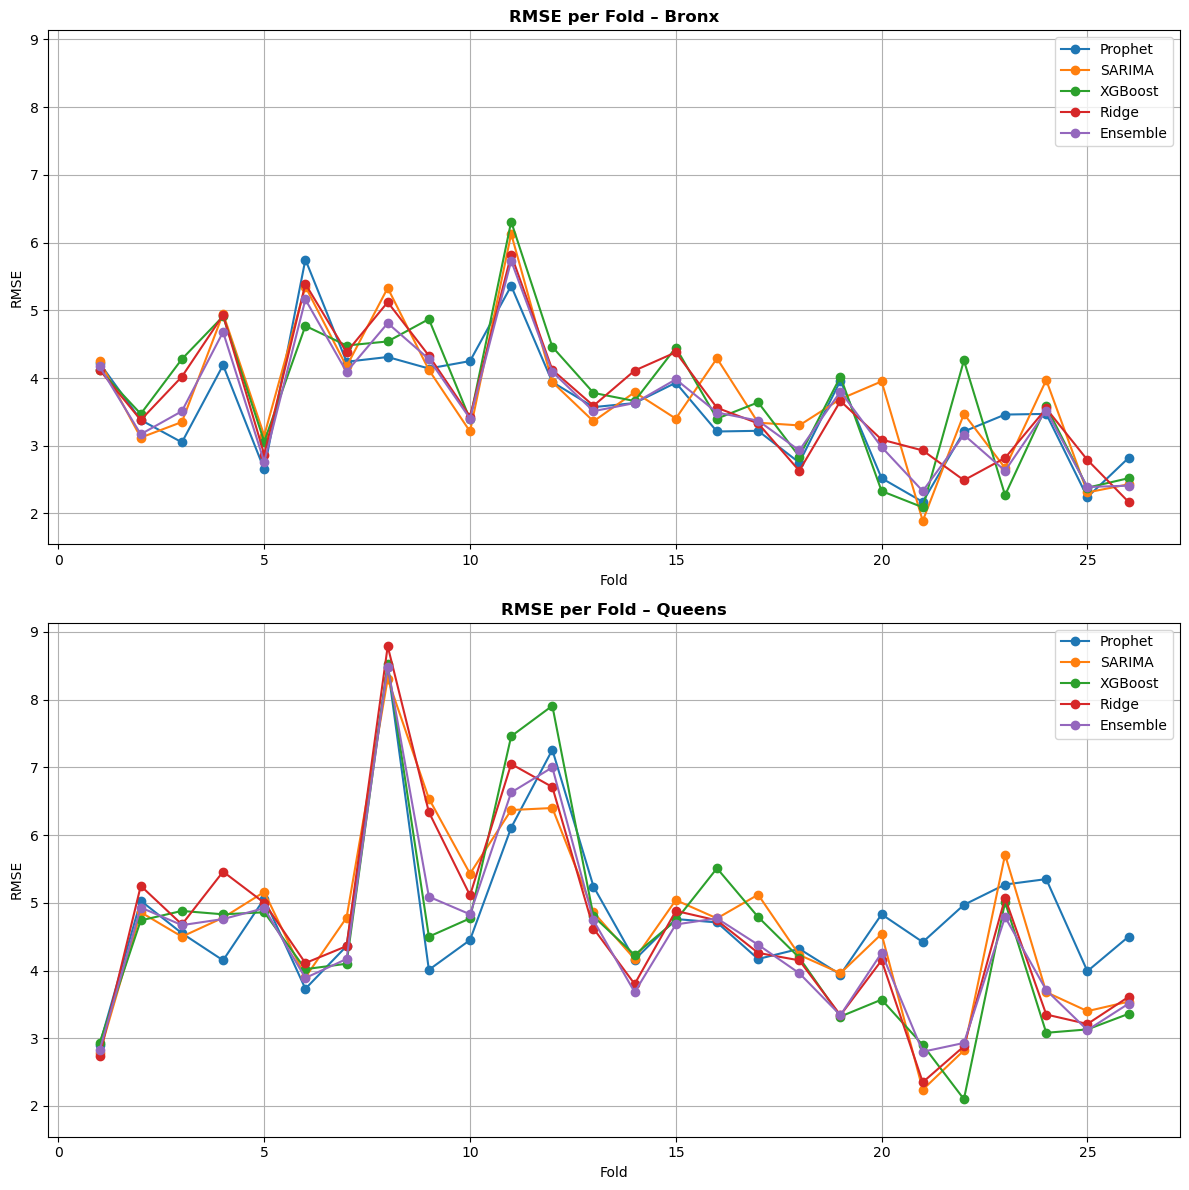

In [11]:
boroughs = wf_multi_all["borough"].unique()
models = ["Prophet", "SARIMA", "XGBoost", "Ridge", "Ensemble"]

fig, axes = plt.subplots(len(boroughs), 1, figsize=(12, 6 * len(boroughs)), sharey=True)

for ax, borough in zip(axes, boroughs):
    df = wf_multi_all[wf_multi_all["borough"] == borough].copy()
    df = df[df["fold"] != "overall"]  # exclude the overall row
    df = df.sort_values("fold")
    
    for model in models:
        ax.plot(df["fold"], df[f"RMSE_{model}"], marker='o', label=model)
    
    ax.set_title(f"RMSE per Fold – {borough}", fontweight="bold")
    ax.set_xlabel("Fold")
    ax.set_ylabel("RMSE")
    ax.grid()
    ax.legend()

plt.tight_layout()
plt.show()

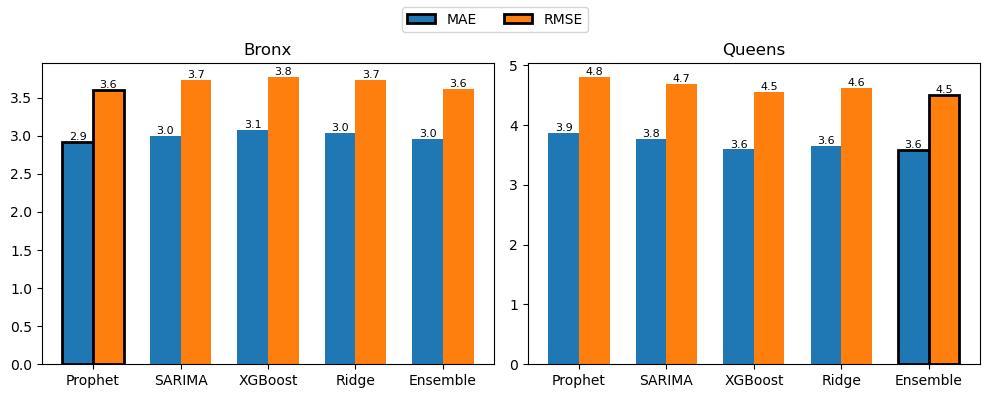

In [12]:
fig,axes=plt.subplots(1,2,figsize=(10,4))
models=["Prophet","SARIMA","XGBoost","Ridge","Ensemble"]

for ax,df,name in zip(axes,[wf_multi_bronx,wf_multi_queens],["Bronx","Queens"]):
    df=df[df["fold"]!="overall"]
    mae=[df[f"MAE_{m}"].mean() for m in models]
    rmse=[df[f"RMSE_{m}"].mean() for m in models]
    x=np.arange(len(models)); w=0.35

    b1=ax.bar(x-w/2,mae,w,label="MAE")
    b2=ax.bar(x+w/2,rmse,w,label="RMSE")

    b1[np.argmin(mae)].set_edgecolor("black"); b1[np.argmin(mae)].set_linewidth(2)
    b2[np.argmin(rmse)].set_edgecolor("black"); b2[np.argmin(rmse)].set_linewidth(2)

    for bars in (b1,b2):
        for bar in bars:
            ax.text(bar.get_x()+bar.get_width()/2,
                    bar.get_height(),
                    f"{bar.get_height():.1f}",
                    ha="center",va="bottom",fontsize=8)

    ax.set_xticks(x); ax.set_xticklabels(models)
    ax.set_title(name)

# One shared legend
fig.legend(["MAE","RMSE"], loc="upper center", ncol=2)

plt.tight_layout()
plt.subplots_adjust(top=0.85)
plt.show()

For the Bronx, the ensemble model and prophet model perform essentially the same. Meanwhile, for queens, the ensemble model performs better, but not by very wide margin. Here, we are using RMSE as the main KPI. RMSE is more representative of our interests because there are large spikes in the number of rat sightings by day and we would like to capture that sort of information as much as possible. Since the chosen Ensemble model performs essentially the same as Prophet and Prophet performed the best for both, we will use Prophet when fitting the final model.

# Evaluating Prophet Model on the Holdout

We do one final evaluation of the Prophet model on the holdout set of 2025-03-01 to 2026-02-28 inclusove.

In [13]:
rats_raw = pd.read_csv(DATA_DIR / "rat_sightings_data" / "Rat_Sightings_NYC.csv")
rats = clean_rats(rats_raw)

def evaluation_build_daily(df, borough, cutoff_date="2026-03-01"):
    cutoff_date = pd.to_datetime(cutoff_date)
    sub = (df[df["borough"] == borough]
           .dropna(subset=["created_dt"])
           .groupby(df["created_dt"].dt.date)
           .size()
           .reset_index())
    sub.columns = ["ds", "count"]
    sub["ds"] = pd.to_datetime(sub["ds"])
    sub = sub.sort_values("ds")

    full = pd.date_range(sub["ds"].min(), sub["ds"].max(), freq="D")
    sub = sub.set_index("ds").reindex(full, fill_value=0).rename_axis("ds").reset_index()

    sub = sub[sub["ds"] < cutoff_date]

    return sub

# Build daily data with cutoff before 2026-03-01
daily_bronx  = evaluation_build_daily(rats, "BRONX", cutoff_date="2026-03-01")
daily_queens = evaluation_build_daily(rats, "QUEENS", cutoff_date="2026-03-01")

In [14]:
def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

def prophet_walkforward(daily_df, borough):
    tscv    = TimeSeriesSplit(n_splits=N_SPLITS, test_size=TEST_SIZE)
    records = []

    for fold, (tr_idx, te_idx) in enumerate(tscv.split(daily_df)):
        
        train = daily_df.iloc[tr_idx].copy()
        test  = daily_df.iloc[te_idx].copy()

        m = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False, 
                    seasonality_mode="additive", changepoint_prior_scale=0.05, interval_width=0.80)
        m.add_country_holidays(country_name="US")

        # fit the model
        m.fit(train.rename(columns={"count": "y"}))

        # have the model make a TEST_SIZE length forecast
        future   = m.make_future_dataframe(periods=TEST_SIZE, freq="D")
        forecast = m.predict(future)
        
        # get the actual forecasts -- this is due to how Prophet's make_future_dataframe functions
        forecast["yhat"] = forecast["yhat"].clip(lower=0)


        
        fc     = forecast.set_index("ds")["yhat"].reindex(pd.DatetimeIndex(test["ds"]), fill_value=0)
        actual = test.set_index("ds")["count"].reindex(fc.index, fill_value=0)


        records.append({"borough": borough, "fold": fold + 1, 
                        "test_start": test["ds"].min().date(),
                        "test_end": test["ds"].max().date(), 
                        "MAE": round(mean_absolute_error(actual, fc), 2), 
                        "RMSE": round(rmse(actual, fc), 2),})

    df = pd.DataFrame(records)

    # Compute overall metrics
    overall = pd.DataFrame([{"borough": borough, "fold": "overall", "test_start": pd.NaT, 
                             "test_end": pd.NaT, "MAE": f"{df['MAE'].mean():.2f}"
                             , "RMSE": f"{df['RMSE'].mean():.2f}"}])

    return pd.concat([df, overall], ignore_index=True)

# Example usage
wf_bronx  = prophet_walkforward(daily_bronx,  "Bronx")
wf_queens = prophet_walkforward(daily_queens, "Queens")

# Combine both boroughs into a single DataFrame for display
wf_all = pd.concat([wf_bronx, wf_queens], ignore_index=True)
wf_all

10:57:09 - cmdstanpy - INFO - Chain [1] start processing
10:57:09 - cmdstanpy - INFO - Chain [1] done processing
10:57:10 - cmdstanpy - INFO - Chain [1] start processing
10:57:10 - cmdstanpy - INFO - Chain [1] done processing
10:57:10 - cmdstanpy - INFO - Chain [1] start processing
10:57:10 - cmdstanpy - INFO - Chain [1] done processing
10:57:11 - cmdstanpy - INFO - Chain [1] start processing
10:57:11 - cmdstanpy - INFO - Chain [1] done processing
10:57:11 - cmdstanpy - INFO - Chain [1] start processing
10:57:12 - cmdstanpy - INFO - Chain [1] done processing
10:57:12 - cmdstanpy - INFO - Chain [1] start processing
10:57:12 - cmdstanpy - INFO - Chain [1] done processing
10:57:12 - cmdstanpy - INFO - Chain [1] start processing
10:57:13 - cmdstanpy - INFO - Chain [1] done processing
10:57:13 - cmdstanpy - INFO - Chain [1] start processing
10:57:13 - cmdstanpy - INFO - Chain [1] done processing
10:57:14 - cmdstanpy - INFO - Chain [1] start processing
10:57:14 - cmdstanpy - INFO - Chain [1]

,borough,fold,test_start,test_end,MAE,RMSE
0,Bronx,1,2025-03-02,2025-03-15,3.09,4.38
1,Bronx,2,2025-03-16,2025-03-29,2.63,3.41
2,Bronx,3,2025-03-30,2025-04-12,3.2,4.41
3,Bronx,4,2025-04-13,2025-04-26,3.67,4.28
4,Bronx,5,2025-04-27,2025-05-10,3.8,4.33
5,Bronx,6,2025-05-11,2025-05-24,2.0,2.37
6,Bronx,7,2025-05-25,2025-06-07,4.28,5.06
7,Bronx,8,2025-06-08,2025-06-21,2.76,3.43
8,Bronx,9,2025-06-22,2025-07-05,2.61,4.19
9,Bronx,10,2025-07-06,2025-07-19,4.28,5.52


# Final Fitting of Prophet Model to Entire Data

In [15]:
# We need to load the data one more time for the final fit.

rats_raw = pd.read_csv(DATA_DIR / "rat_sightings_data" / "Rat_Sightings_NYC.csv")
rats = clean_rats(rats_raw)

def recent_build_daily(df, borough):
    sub = (df[df["borough"] == borough].dropna(subset=["created_dt"]).groupby(df["created_dt"].dt.date).size().reset_index())
    sub.columns = ["ds", "count"]
    sub["ds"] = pd.to_datetime(sub["ds"])
    sub = sub.sort_values("ds")

    full = pd.date_range(sub["ds"].min(), sub["ds"].max(), freq="D")
    sub = sub.set_index("ds").reindex(full, fill_value=0).rename_axis("ds").reset_index()
    return sub

daily_bronx  = recent_build_daily(rats, "BRONX")
daily_queens = recent_build_daily(rats, "QUEENS")


In [16]:
FORECAST_DAYS = 14

def fit_final_prophet(daily_df, borough):
    train = daily_df.copy()
    m = Prophet(yearly_seasonality=True, weekly_seasonality=True,
                daily_seasonality=False, seasonality_mode="additive",
                changepoint_prior_scale=0.05, interval_width=0.80)
    m.add_country_holidays(country_name="US")
    m.fit(train.rename(columns={"count":"y"}))

    future   = m.make_future_dataframe(periods=FORECAST_DAYS, freq="D")
    forecast = m.predict(future)
    forecast["yhat"]       = forecast["yhat"].clip(lower=0)
    forecast["yhat_lower"] = forecast["yhat_lower"].clip(lower=0)

    fc_future = forecast.iloc[-15:].copy()
    return m, fc_future, forecast

m_bronx,  fc_bronx,  full_fc_bronx  = fit_final_prophet(daily_bronx,  "Bronx")
m_queens, fc_queens, full_fc_queens = fit_final_prophet(daily_queens, "Queens")

10:57:44 - cmdstanpy - INFO - Chain [1] start processing
10:57:44 - cmdstanpy - INFO - Chain [1] done processing
10:57:45 - cmdstanpy - INFO - Chain [1] start processing
10:57:45 - cmdstanpy - INFO - Chain [1] done processing


In [17]:
display(fc_bronx[["ds", "yhat", "yhat_lower", "yhat_upper"]].assign(ds=lambda x: x["ds"].dt.date)
        .style.set_caption("Bronx - 14-Day Forecast").format(precision=0))

display(fc_queens[["ds", "yhat", "yhat_lower", "yhat_upper"]].assign(ds=lambda x: x["ds"].dt.date)
        .style.set_caption("Queens - 14-Day Forecast").format(precision=0))

,ds,yhat,yhat_lower,yhat_upper
2257,2026-03-07,4,0,9
2258,2026-03-08,4,0,9
2259,2026-03-09,9,4,14
2260,2026-03-10,9,4,13
2261,2026-03-11,8,3,13
2262,2026-03-12,9,4,14
2263,2026-03-13,7,3,12
2264,2026-03-14,4,0,9
2265,2026-03-15,4,0,9
2266,2026-03-16,9,4,14


,ds,yhat,yhat_lower,yhat_upper
2258,2026-03-08,3,0,8
2259,2026-03-09,8,2,13
2260,2026-03-10,7,2,13
2261,2026-03-11,7,2,12
2262,2026-03-12,7,1,11
2263,2026-03-13,6,0,11
2264,2026-03-14,3,0,8
2265,2026-03-15,3,0,8
2266,2026-03-16,8,3,13
2267,2026-03-17,7,2,12


# Plotting the 14-Day Forecast

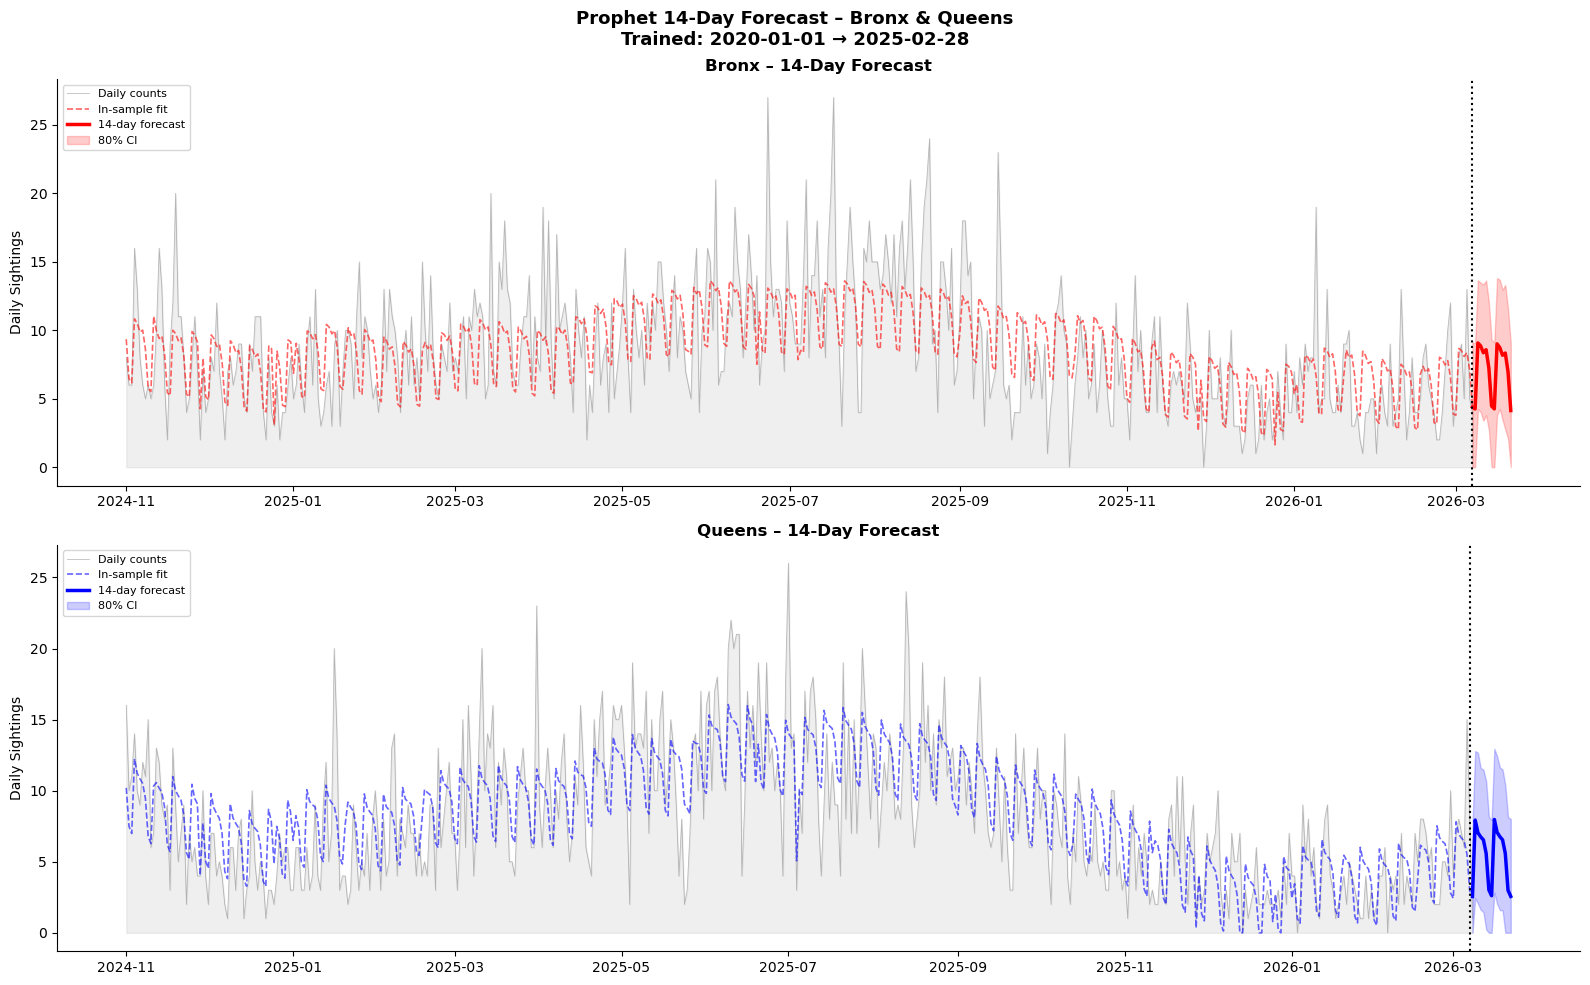

In [18]:
# Set DATA_CUTOFF as the last date in daily_bronx
FINAL_CUTOFF = daily_bronx["ds"].max()

def plot_forecast(ax, train_df, fc_future, full_fc, name, color, start_date="2024-11-01"):
    start_date = pd.to_datetime(start_date)

    hist = train_df[train_df["ds"] >= start_date].copy()

    ax.fill_between(hist["ds"], hist["count"], alpha=0.12, color="gray")
    ax.plot(hist["ds"], hist["count"], color="gray", lw=0.6, alpha=0.5, label="Daily counts")

    # in sample forecast
    fit_part = full_fc[full_fc["ds"] >= start_date]
    ax.plot(fit_part["ds"], fit_part["yhat"], color=color, lw=1.2, linestyle="--", alpha=0.6, label="In-sample fit")

    # 14 day future forecast
    fc_future_part = fc_future[fc_future["ds"] >= start_date]
    ax.plot(fc_future_part["ds"], fc_future_part["yhat"], color=color, lw=2.5, label="14-day forecast")
    ax.fill_between(fc_future_part["ds"], fc_future_part["yhat_lower"], 
                    fc_future_part["yhat_upper"], color=color, alpha=0.2, label="80% CI")

    # cut off line for viewer
    ax.axvline(FINAL_CUTOFF, color="black", linestyle=":", lw=1.5)

    ax.set_title(f"{name} – 14-Day Forecast", fontweight="bold")
    ax.set_ylabel("Daily Sightings")
    ax.legend(fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)


# plot for bronx and queens separately
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

plot_forecast(axes[0], daily_bronx, fc_bronx, full_fc_bronx, "Bronx", "red", start_date="2024-11-01")
plot_forecast(axes[1], daily_queens, fc_queens, full_fc_queens, "Queens", "blue", start_date="2024-11-01")

plt.suptitle(f"Prophet 14-Day Forecast – Bronx & Queens\n"
             f"Trained: {daily_bronx['ds'].min().date()} → {DATA_CUTOFF.date()}",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Plotting to see Seasonal Patterns 

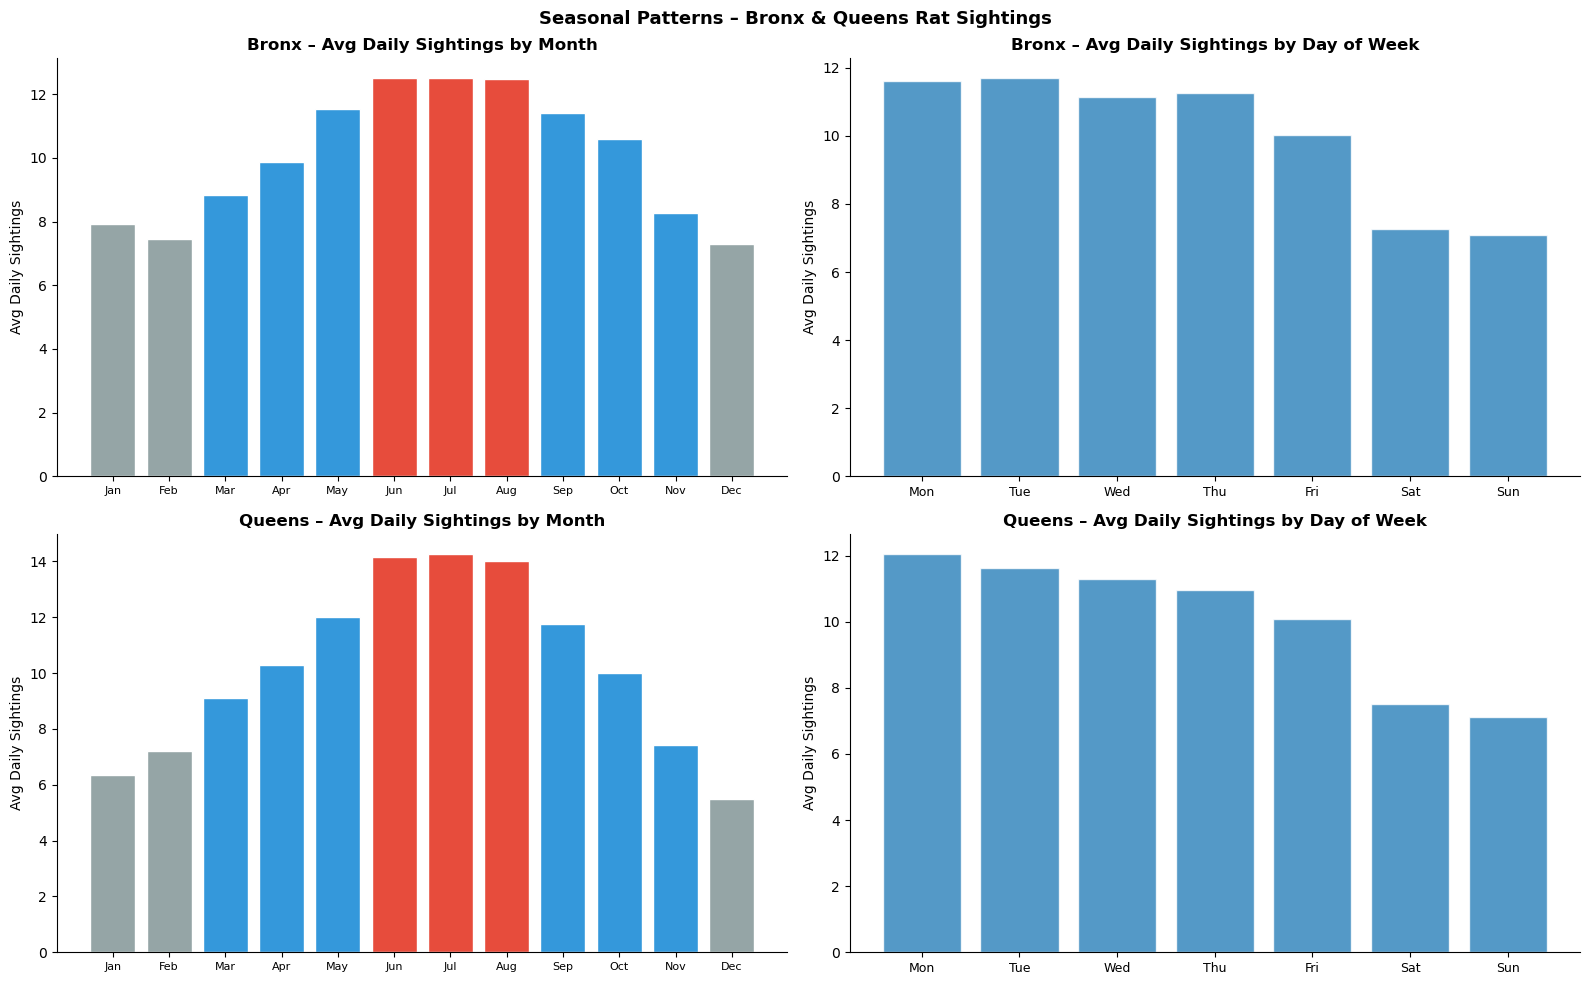

In [19]:
# Cell 19 – seasonal patterns (monthly + day-of-week)
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
month_names = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
day_names   = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]

for row_ax, daily_df, name in zip([axes[0], axes[1]],
                                   [daily_bronx, daily_queens],
                                   ["Bronx", "Queens"]):
    # monthly
    ax = row_ax[0]
    monthly = daily_df.assign(month=daily_df["ds"].dt.month).groupby("month")["count"].mean()
    bar_c = ["#e74c3c" if m in [6,7,8] else "#95a5a6" if m in [12,1,2] else "#3498db"
             for m in monthly.index]
    ax.bar(monthly.index, monthly.values, color=bar_c, edgecolor="white")
    ax.set_xticks(range(1,13)); ax.set_xticklabels(month_names, fontsize=8)
    ax.set_title(f"{name} – Avg Daily Sightings by Month", fontweight="bold")
    ax.set_ylabel("Avg Daily Sightings")
    ax.spines[["top","right"]].set_visible(False)

    # day of week
    ax = row_ax[1]
    dow = daily_df.assign(dow=daily_df["ds"].dt.dayofweek).groupby("dow")["count"].mean()
    ax.bar(dow.index, dow.values, color="#2980b9", edgecolor="white", alpha=0.8)
    ax.set_xticks(range(7)); ax.set_xticklabels(day_names, fontsize=9)
    ax.set_title(f"{name} – Avg Daily Sightings by Day of Week", fontweight="bold")
    ax.set_ylabel("Avg Daily Sightings")
    ax.spines[["top","right"]].set_visible(False)

plt.suptitle("Seasonal Patterns – Bronx & Queens Rat Sightings", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Conclusions

The goal was to make predictions for 311 rat sightings report in Bronx and Queens for the next 14 days. The best model for Queens and and Bronx were respectively Prophet and the Ensemble model. These models certainly perform better than the citywide forecasts that were obtained due to less noise and the amount of 311 rat sightings are lower. We might have selected Prophet as our final models here, but it is possible that improvements can be made if we tune parameters and add exogeneous features. This will/should be done in another notebook.